Problem 1: Environment Verification

In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib

print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("Matplotlib version:", matplotlib.__version__)

# Check GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    print("GPU is available")
else:
    print("GPU NOT available")

TensorFlow version: 2.19.0
NumPy version: 2.0.2
Pandas version: 2.2.2
Matplotlib version: 3.10.0
GPU NOT available


In [ ]:
import random
import numpy as np
import tensorflow as tf

random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

Problem 2: Dataset Exploration

In [ ]:
from tensorflow.keras.datasets import mnist, cifar10

(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = cifar10.load_data()

print("MNIST train shape:", x_train_mnist.shape)
print("MNIST test shape:", x_test_mnist.shape)

print("CIFAR train shape:", x_train_cifar.shape)
print("CIFAR test shape:", x_test_cifar.shape)

print("MNIST dtype:", x_train_mnist.dtype)
print("MNIST range:", x_train_mnist.min(), x_train_mnist.max())

print("CIFAR dtype:", x_train_cifar.dtype)

import numpy as np
unique, counts = np.unique(y_train_mnist, return_counts=True)
print(dict(zip(unique, counts)))

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
MNIST train shape: (60000, 28, 28)
MNIST test shape: (10000, 28, 28)
CIFAR train shape: (50000, 32, 32, 3)
CIFAR test shape: (10000, 32, 32, 3)
MNIST dtype: uint8
MNIST range: 0 255
CIFAR dtype: uint8
CIFAR range: 0 255
{np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}


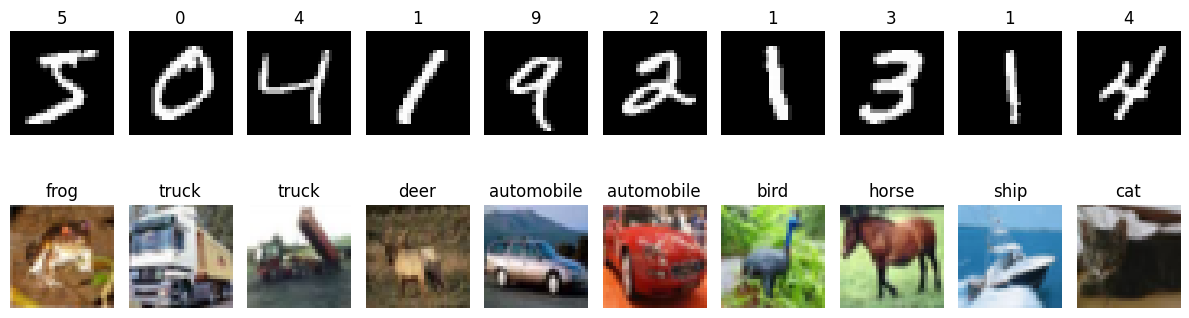

In [ ]:
import matplotlib.pyplot as plt

# CIFAR class names
classes = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

plt.figure(figsize=(12,4))

# MNIST
for i in range(10):
    plt.subplot(2,10,i+1)
    plt.imshow(x_train_mnist[i], cmap='gray')
    plt.title(y_train_mnist[i])
    plt.axis('off')

# CIFAR
for i in range(10):
    plt.subplot(2,10,i+11)
    plt.imshow(x_train_cifar[i])
    plt.title(classes[y_train_cifar[i][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

Problem 3  Preprocessing Pipeline

In [ ]:
import numpy as np
from tensorflow.keras.datasets import mnist

# Load data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

def preprocess_data(images, labels):

    print("===== BEFORE PROCESSING =====")
    print("Shape:", images.shape)
    print("Dtype:", images.dtype)
    print("Min/Max:", images.min(), images.max())

    # Step 1: Normalize
    images = images.astype('float32') / 255.0

    print("\n===== AFTER NORMALIZATION =====")
    print("Dtype:", images.dtype)
    print("Min/Max:", images.min(), images.max())
    print("Sample values:", images[0][0][:5])

    # Step 2: Reshape
    images = images.reshape(images.shape[0], 28, 28, 1)

    print("\n===== AFTER RESHAPING =====")
    print("Shape:", images.shape)

    # Step 3: One-hot encoding
    num_classes = 10
    one_hot = np.zeros((labels.shape[0], num_classes))
    one_hot[np.arange(labels.shape[0]), labels] = 1

    print("\n===== AFTER ONE-HOT ENCODING =====")
    print("Shape:", one_hot.shape)
    print("First 5 labels:", one_hot[:5])

    return images, one_hot

processed_images, processed_labels = preprocess_data(x_train, y_train)

===== BEFORE PROCESSING =====
Shape: (60000, 28, 28)
Dtype: uint8
Min/Max: 0 255

===== AFTER NORMALIZATION =====
Dtype: float32
Min/Max: 0.0 1.0
Sample values: [0. 0. 0. 0. 0.]

===== AFTER RESHAPING =====
Shape: (60000, 28, 28, 1)

===== AFTER ONE-HOT ENCODING =====
Shape: (60000, 10)
First 5 labels: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


PROBLEM 4 WITH OUTPUT DISPLAY

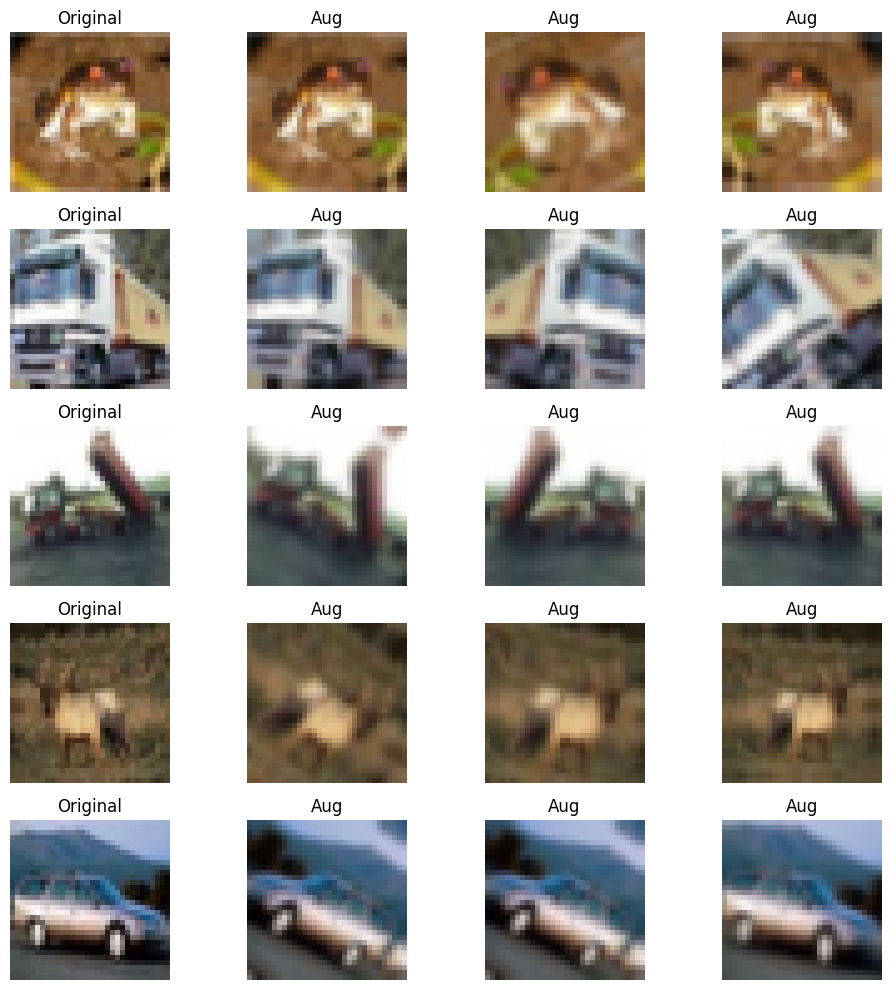

In [ ]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import cifar10

# Load CIFAR
(x_train, y_train), _ = cifar10.load_data()

# Define augmentation
data_aug = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1)
])

# Plot
plt.figure(figsize=(10,10))

for i in range(5):
    original = x_train[i]

    # Original image
    plt.subplot(5,4,4*i+1)
    plt.imshow(original.astype("uint8"))
    plt.title("Original")
    plt.axis("off")

    # Augmented versions
    for j in range(3):
        aug_img = data_aug(tf.expand_dims(original, 0))
        plt.subplot(5,4,4*i+2+j)
        plt.imshow(aug_img[0].numpy().astype("uint8"))
        plt.title("Aug")
        plt.axis("off")

plt.tight_layout()
plt.savefig("augmentation_demo.png")
plt.show()

TASK 02    
Problem 1: Manual conv2d (NumPy ONLY)



In [ ]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):
    # Add padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    img_h, img_w = image.shape
    k_h, k_w = kernel.shape

    # Output size
    out_h = (img_h - k_h) // stride + 1
    out_w = (img_w - k_w) // stride + 1

    output = np.zeros((out_h, out_w))

    # Convolution
    for i in range(out_h):
        for j in range(out_w):
            region = image[i*stride:i*stride+k_h, j*stride:j*stride+k_w]
            output[i, j] = np.sum(region * kernel)

    return output

image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

kernel = np.array([
    [-1,0,1],
    [-2,0,2],
    [-1,0,1]
])

result = conv2d(image, kernel, stride=1, padding=0)

print("Output:\n", result)

Output:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]


Problem 3: LeNet-5 (TensorFlow Code)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1), padding='valid'),
    layers.AveragePooling2D((2,2), strides=2),

    layers.Conv2D(16, (5,5), activation='tanh'),
    layers.AveragePooling2D((2,2), strides=2),

    layers.Flatten(),
    layers.Dense(120, activation='tanh'),
    layers.Dense(84, activation='tanh'),
    layers.Dense(10, activation='softmax')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

Problem 4: Custom CNN (CIFAR-10)

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), padding='same'),
    layers.BatchNormalization(),
    layers.ReLU(),
    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

TASK 03    


Problem 1: First Training Run

In [48]:
import tensorflow as tf
from tensorflow.keras import datasets

# Load data
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Preprocess
x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1,28,28,1)
x_test = x_test.reshape(-1,28,28,1)

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

def build_lenet_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(6, (5,5), activation='tanh', input_shape=(28,28,1), padding='valid'),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2),
        tf.keras.layers.Conv2D(16, (5,5), activation='tanh'),
        tf.keras.layers.AveragePooling2D(pool_size=(2,2), strides=2),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(120, activation='tanh'),
        tf.keras.layers.Dense(84, activation='tanh'),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.8290 - loss: 0.6462 - val_accuracy: 0.9262 - val_loss: 0.2700
Epoch 2/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9172 - loss: 0.2847 - val_accuracy: 0.9465 - val_loss: 0.1941
Epoch 3/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 40s 16ms/step - accuracy: 0.9362 - loss: 0.2171 - val_accuracy: 0.9588 - val_loss: 0.1535
Epoch 4/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9485 - loss: 0.1748 - val_accuracy: 0.9650 - val_loss: 0.1269
Epoch 5/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9573 - loss: 0.1457 - val_accuracy: 0.9690 - val_loss: 0.1087
Epoch 6/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9633 - loss: 0.1249 - val_accuracy: 0.9730 - val_loss: 0.0958
Epoch 7/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.9682 - loss: 0.1093 - val_accuracy: 0.9747 - val_loss: 0.0865
Epoch 8/15
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9714 -

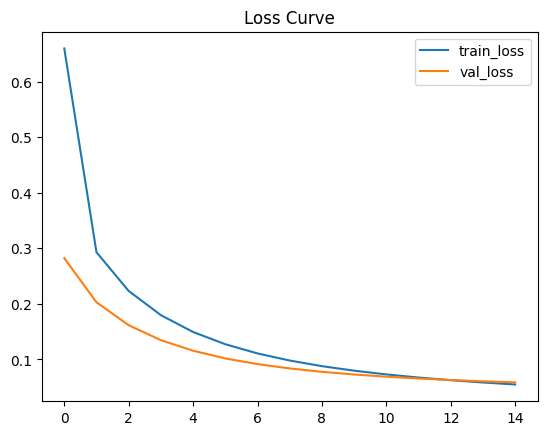

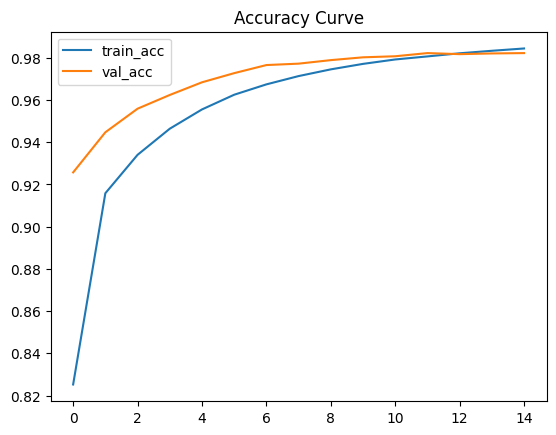

In [ ]:
# Loss plot
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.legend()
plt.title("Loss Curve")
plt.savefig("lenet_sgd_curves.png")
plt.show()

# Accuracy plot
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

Problem 2: Optimizer Comparison

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
class LeNet5(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(1, 6, 5),
            nn.ReLU(),
            nn.AvgPool2d(2),
            nn.Conv2d(6, 16, 5),
            nn.ReLU(),
            nn.AvgPool2d(2)
        )
        self.fc = nn.Sequential(
            nn.Linear(16*4*4, 120),
            nn.ReLU(),
            nn.Linear(120, 84),
            nn.ReLU(),
            nn.Linear(84, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)

In [5]:
transform = transforms.ToTensor()

dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=64)

test_ds = torchvision.datasets.MNIST(root='./data', train=False, transform=transform)
test_loader = DataLoader(test_ds, batch_size=64)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 487kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.19MB/s]


In [9]:
optimizers = {
    "SGD": optim.SGD,
    "Momentum": lambda params: optim.SGD(params, lr=0.01, momentum=0.9),
    "Adam": optim.Adam
}

results = {}

for name, opt in optimizers.items():
    model = LeNet5().to(device)

    if name == "Momentum":
        optimizer = opt(model.parameters())
    elif name == "Adam":
        optimizer = opt(model.parameters(), lr=0.001)
    else:
        optimizer = opt(model.parameters(), lr=0.01)

    print(f"\nTraining with {name}")
    results[name] = train_model(model, optimizer)


Training with SGD
Epoch 1: Train Acc=0.1067, Val Acc=0.1092
Epoch 2: Train Acc=0.1127, Val Acc=0.1092
Epoch 3: Train Acc=0.1277, Val Acc=0.3503
Epoch 4: Train Acc=0.6972, Val Acc=0.8082
Epoch 5: Train Acc=0.8731, Val Acc=0.8902
Epoch 6: Train Acc=0.9070, Val Acc=0.9148
Epoch 7: Train Acc=0.9251, Val Acc=0.9225
Epoch 8: Train Acc=0.9366, Val Acc=0.9310
Epoch 9: Train Acc=0.9447, Val Acc=0.9540
Epoch 10: Train Acc=0.9504, Val Acc=0.9578
Epoch 11: Train Acc=0.9554, Val Acc=0.9585
Epoch 12: Train Acc=0.9597, Val Acc=0.9583
Epoch 13: Train Acc=0.9625, Val Acc=0.9640
Epoch 14: Train Acc=0.9661, Val Acc=0.9698
Epoch 15: Train Acc=0.9679, Val Acc=0.9692

Training with Momentum
Epoch 1: Train Acc=0.7610, Val Acc=0.9382
Epoch 2: Train Acc=0.9571, Val Acc=0.9657
Epoch 3: Train Acc=0.9716, Val Acc=0.9752
Epoch 4: Train Acc=0.9786, Val Acc=0.9793
Epoch 5: Train Acc=0.9821, Val Acc=0.9817
Epoch 6: Train Acc=0.9856, Val Acc=0.9825
Epoch 7: Train Acc=0.9868, Val Acc=0.9847
Epoch 8: Train Acc=0.9882, 

Problem 3 :Learning Rate & Batch Size Grid Search

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models

(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()
x_train = x_train.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_train = tf.keras.utils.to_categorical(y_train, 10)
x_test = x_test.reshape(-1, 28, 28, 1).astype('float32') / 255.0
y_test = tf.keras.utils.to_categorical(y_test, 10)

def build_lenet_model():
    model = models.Sequential([
        layers.Conv2D(6, (5, 5), activation='tanh', input_shape=(28, 28, 1), padding='valid'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        layers.Conv2D(16, (5, 5), activation='tanh'),
        layers.AveragePooling2D(pool_size=(2, 2), strides=2),
        layers.Flatten(),
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])
    return model

learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

for lr in learning_rates:
    for bs in batch_sizes:

        model = build_lenet_model()
        model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
                      loss='categorical_crossentropy',
                      metrics=['accuracy'])

        print(f"\nTraining with LR: {lr}, Batch Size: {bs}")
        h = model.fit(x_train, y_train,
                      epochs=10,
                      batch_size=bs,
                      validation_split=0.1,
                      verbose=0)

        results[(lr, bs)] = max(h.history['val_accuracy'])

print("\nGrid Search Results:")
for (lr, bs), acc in results.items():
    print(f"LR: {lr}, BS: {bs}, Max Val Acc: {acc:.4f}")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



Training with LR: 0.1, Batch Size: 32

Training with LR: 0.1, Batch Size: 128

Training with LR: 0.01, Batch Size: 32

Training with LR: 0.01, Batch Size: 128

Training with LR: 0.001, Batch Size: 32

Training with LR: 0.001, Batch Size: 128

Grid Search Results:
LR: 0.1, BS: 32, Max Val Acc: 0.1050
LR: 0.1, BS: 128, Max Val Acc: 0.1113
LR: 0.01, BS: 32, Max Val Acc: 0.9678
LR: 0.01, BS: 128, Max Val Acc: 0.9805
LR: 0.001, BS: 32, Max Val Acc: 0.9872
LR: 0.001, BS: 128, Max Val Acc: 0.9880


Problem 4: Regularisation

In [31]:
class RegCNN(nn.Module):
    def __init__(self, use_dropout=False, use_bn=False):
        super().__init__()

        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_bn else nn.Identity()
        self.pool1 = nn.MaxPool2d(2)
        self.drop1 = nn.Dropout(0.3) if use_dropout else nn.Identity()

        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_bn else nn.Identity()
        self.pool2 = nn.MaxPool2d(2)
        self.drop2 = nn.Dropout(0.3) if use_dropout else nn.Identity()


        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.drop_fc = nn.Dropout(0.5) if use_dropout else nn.Identity()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):

        x = self.pool1(torch.relu(self.bn1(self.conv1(x))))
        x = self.drop1(x)


        x = self.pool2(torch.relu(self.bn2(self.conv2(x))))
        x = self.drop2(x)

        x = x.view(x.size(0), -1)


        x = torch.relu(self.fc1(x))
        x = self.drop_fc(x)
        x = self.fc2(x)

        return x

Problem 5: Learning Rate Scheduling

In [12]:
callback1 = tf.keras.callbacks.ReduceLROnPlateau(
    factor=0.5, patience=3)

callback2 = tf.keras.callbacks.LearningRateScheduler(
    lambda epoch: 0.01 * (0.5 ** epoch))

In [15]:
def train_with_scheduler(model, optimizer, scheduler, use_plateau=False):
    criterion = nn.CrossEntropyLoss()
    val_accs, lrs = [], []

    for epoch in range(30):
        model.train()

        for x, y in train_loader_full:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()

        acc = 0
        with torch.no_grad():
            for x, y in train_loader_full:
                x, y = x.to(device), y.to(device)
                acc += (model(x).argmax(1) == y).sum().item()

        acc /= len(train_loader_full.dataset)
        val_accs.append(acc)
        lrs.append(optimizer.param_groups[0]['lr'])

        if use_plateau:
            scheduler.step(acc)
        else:
            scheduler.step()

    return lrs, val_accs

Task.      
4 Visualisation & Interpretability

Problem 1: Visualise Learned Filters






In [16]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_filters(model):

    weights = model.conv1.weight.data.cpu()
    num_filters = weights.shape[0]

    fig, axes = plt.subplots(4, 8, figsize=(10, 5))
    axes = axes.flatten()

    for i in range(num_filters):
        filt = weights[i]

        filt = filt.numpy()

        filt = np.mean(filt, axis=0)

        filt = (filt - filt.min()) / (filt.max() - filt.min() + 1e-5)

        axes[i].imshow(filt, cmap='gray')
        axes[i].set_title(f"{i}")
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig("conv1_filters.png")
    plt.show()

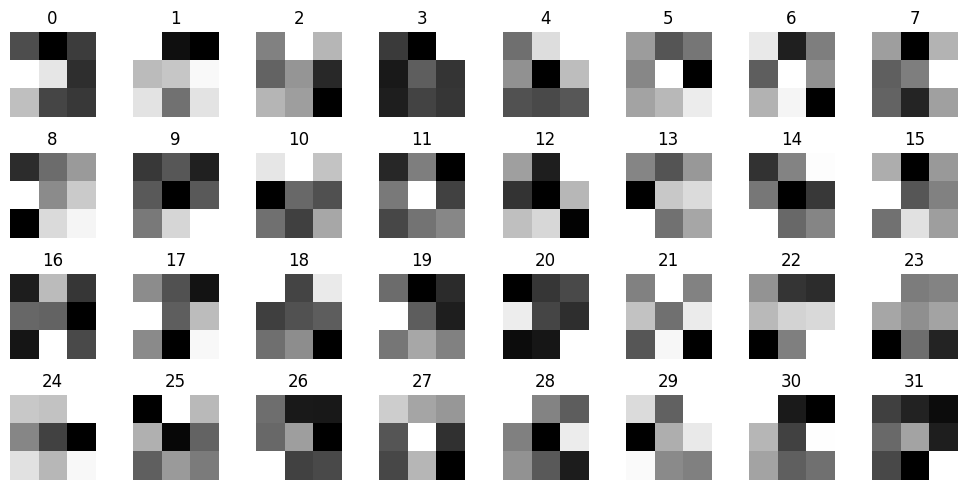

In [17]:
visualize_filters(model)

Problem 2: Feature Maps

In [18]:
feature_maps = {}

def get_features(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

In [29]:

model = RegCNN(use_dropout=True, use_bn=True).to(device)

feature_maps = {}

def get_features(name):
    def hook(model, input, output):
        feature_maps[name] = output.detach()
    return hook

model.conv1.register_forward_hook(get_features("conv1"))
model.conv2.register_forward_hook(get_features("conv2"))

In [23]:
data_iter = iter(test_loader)
images, labels = next(data_iter)

img = images[0].unsqueeze(0).to(device)

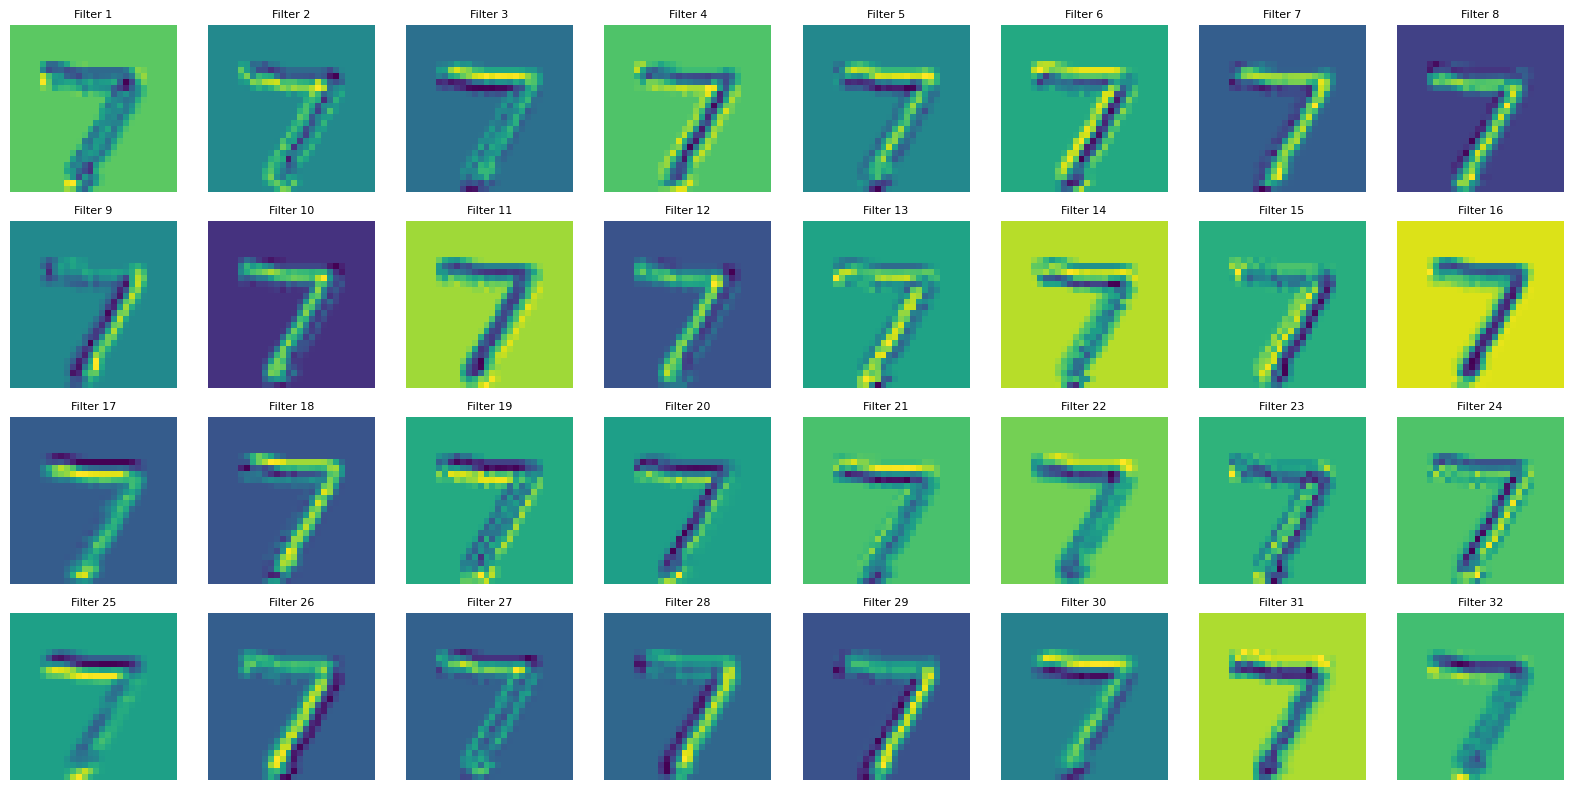

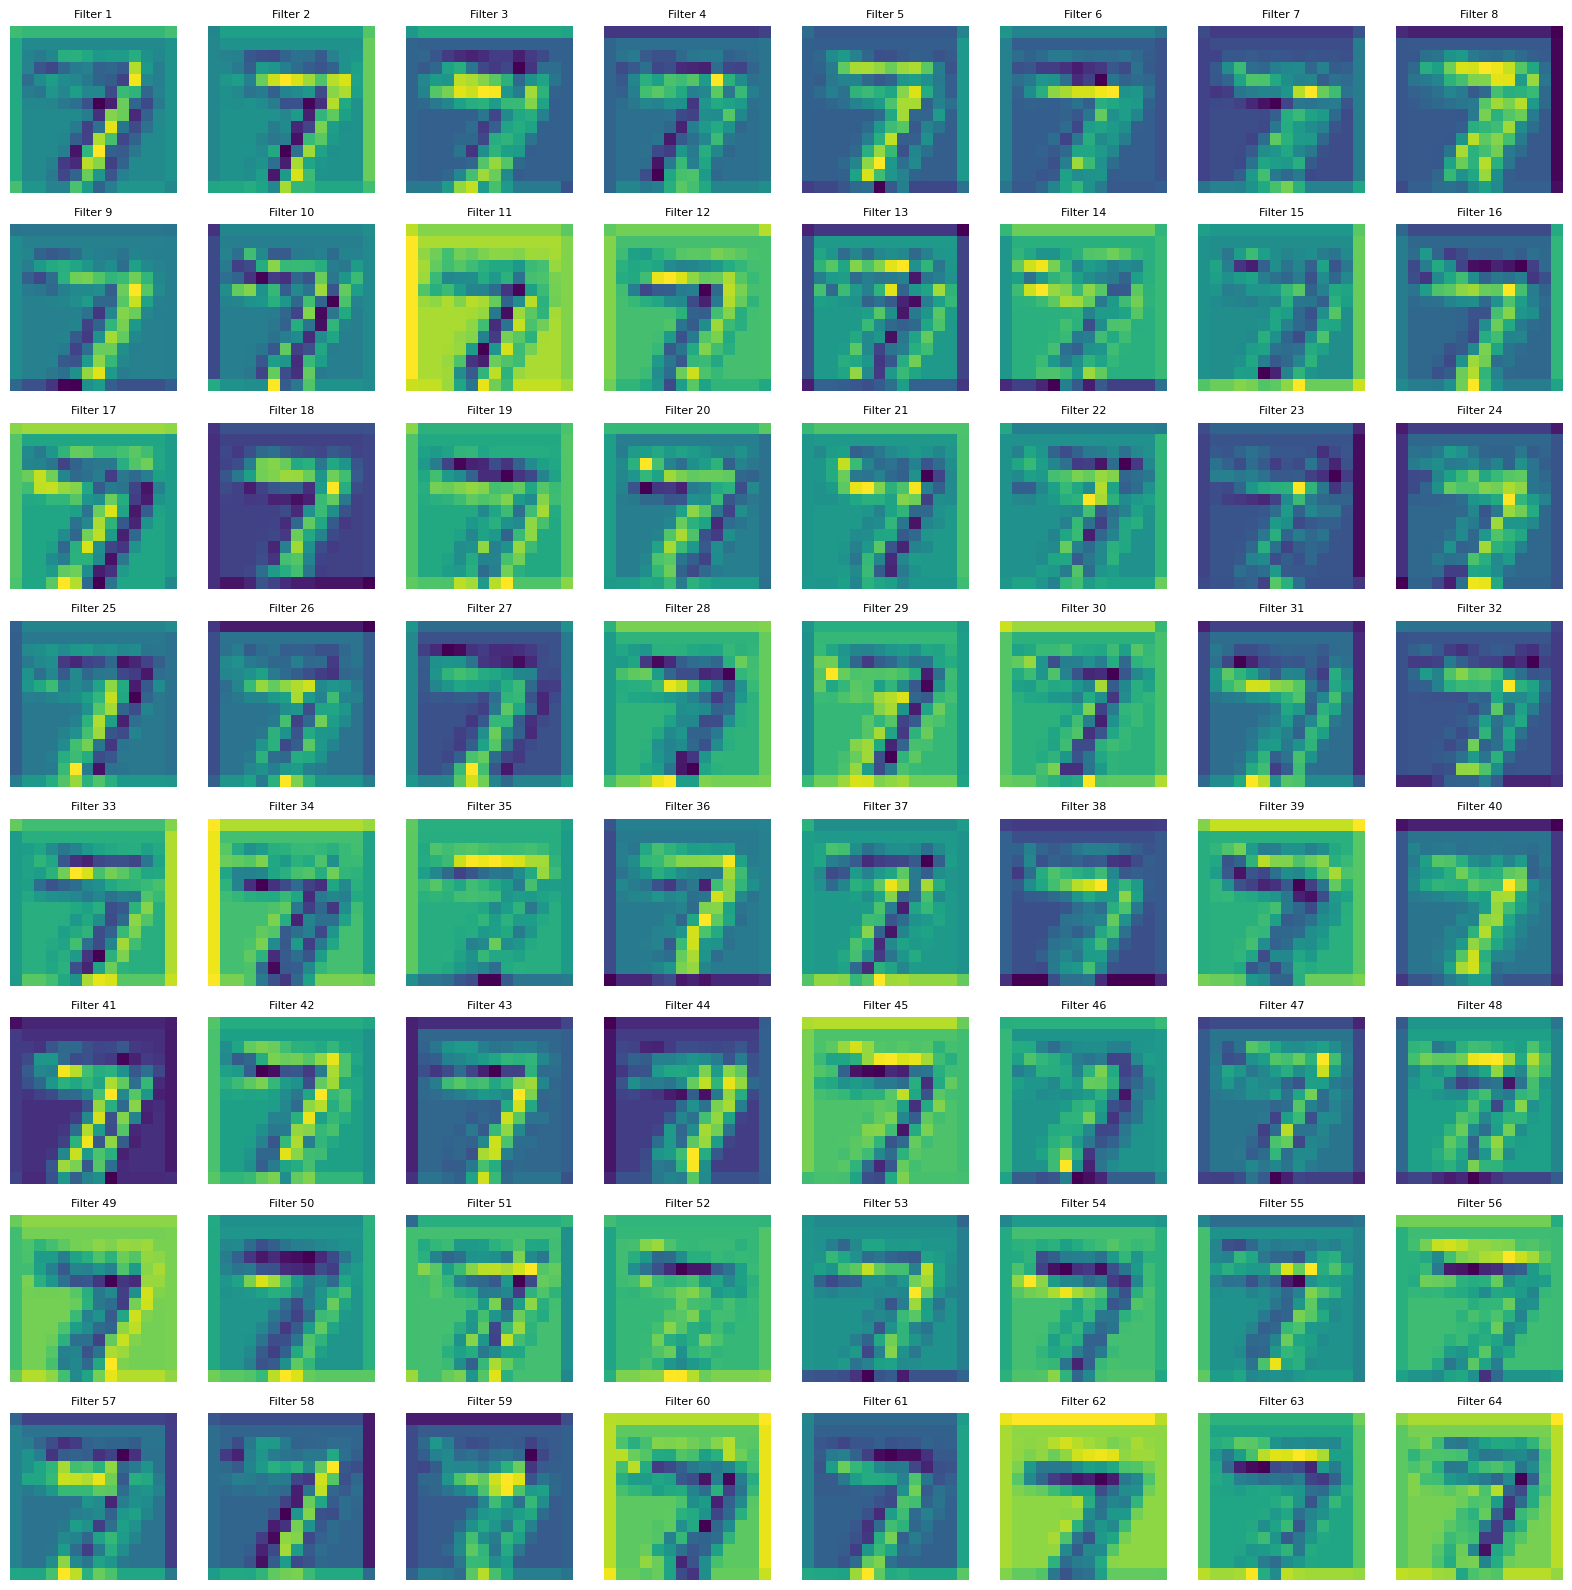

In [32]:
import matplotlib.pyplot as plt

def plot_feature_maps(fmap, filename):
    fmap = fmap.squeeze(0).cpu()

    num_filters = fmap.shape[0]
    cols = min(8, num_filters)
    rows = (num_filters + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
    if rows == 1 and cols == 1:
        axes = np.array([axes])
    axes = axes.flatten()

    for i in range(num_filters):
        axes[i].imshow(fmap[i], cmap='viridis')
        axes[i].set_title(f'Filter {i+1}', fontsize=8)
        axes[i].axis('off')


    for i in range(num_filters, len(axes)):
        axes[i].axis('off')

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

if 'conv1' in feature_maps and 'conv2' in feature_maps:
    plot_feature_maps(feature_maps["conv1"], "fmaps_layer1.png")
    plot_feature_maps(feature_maps["conv2"], "fmaps_last.png")
else:
    print("Feature maps not found. Please ensure the model's forward pass was executed.")

In [33]:
import matplotlib.pyplot as plt

def plot_feature_maps(fmap, filename):
    fmap = fmap[0].cpu()

    num_maps = min(8, fmap.shape[0])

    fig, axes = plt.subplots(1, num_maps, figsize=(15, 3))

    for i in range(num_maps):
        axes[i].imshow(fmap[i], cmap='viridis')
        axes[i].axis('off')
        axes[i].set_title(f"{i}")

    plt.tight_layout()
    plt.savefig(filename)
    plt.show()

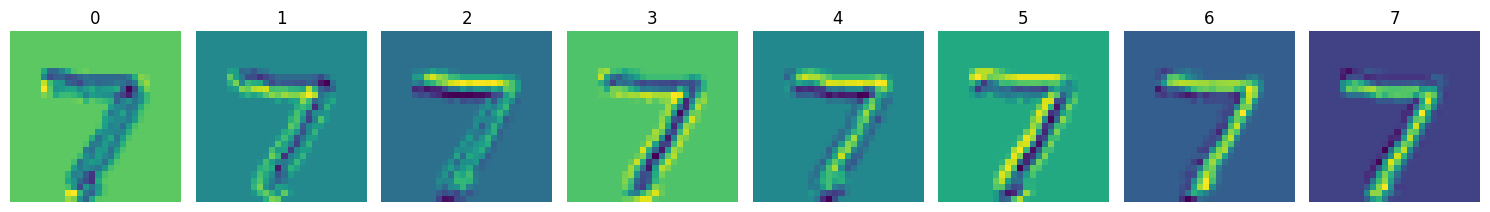

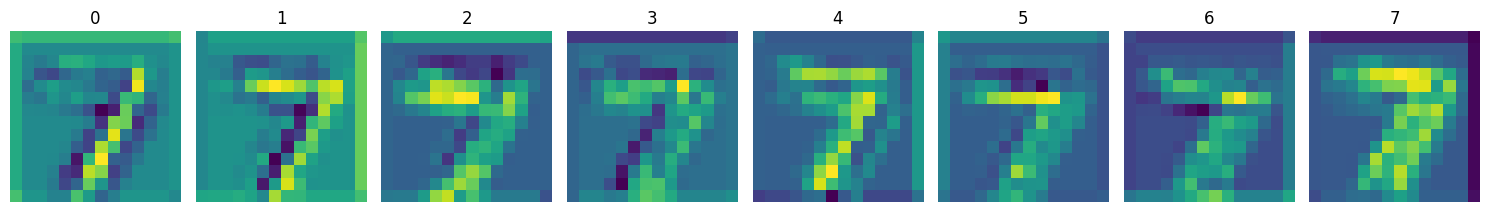

In [34]:
plot_feature_maps(feature_maps["conv1"], "fmaps_layer1.png")
plot_feature_maps(feature_maps["conv2"], "fmaps_last.png")

Problem 3: Grad-CAM (FROM SCRATCH)

In [41]:
gradients = None
activations = None

In [42]:
def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

In [49]:
global gradients, activations
gradients = None
activations = None

def forward_hook(module, input, output):
    global activations
    activations = output

def backward_hook(module, grad_output):
    global gradients
    gradients = grad_output[0]

if hasattr(model.conv2, '_forward_hooks'):
    model.conv2._forward_hooks.clear()
if hasattr(model.conv2, '_backward_hooks'):
    model.conv2._backward_hooks.clear()
if hasattr(model.conv2, '_full_backward_hooks'):
    model.conv2._full_backward_hooks.clear()

handle_fwd_gradcam = model.conv2.register_forward_hook(forward_hook)
handle_bwd_gradcam = model.conv2.register_backward_hook(backward_hook)

print("Grad-CAM hooks registered on model.conv2")

model.eval()

Grad-CAM hooks registered on model.conv2


RegCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop1): Dropout(p=0.3, inplace=False)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (drop2): Dropout(p=0.3, inplace=False)
  (fc1): Linear(in_features=4096, out_features=128, bias=True)
  (drop_fc): Dropout(p=0.5, inplace=False)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

In [44]:
import torch.nn.functional as F
import cv2
import numpy as np

def generate_gradcam(model, image, class_idx=None):
    global gradients, activations

    model.eval()
    gradients = None
    activations = None

    output = model(image)

    if class_idx is None:
        class_idx = output.argmax(dim=1).item()

    score = output[0, class_idx]

    model.zero_grad()
    score.backward()

    if gradients is None or activations is None:
        raise ValueError("Hooks not working — gradients/activations missing")

    grads = gradients[0]
    acts = activations[0]


    weights = torch.mean(grads, dim=(1,2))

    cam = torch.zeros(acts.shape[1:], dtype=torch.float32).to(device)

    for i in range(len(weights)):
        cam += weights[i] * acts[i]

    cam = F.relu(cam)


    cam -= cam.min()
    cam /= (cam.max() + 1e-8)

    cam = cam.detach().cpu().numpy()

    cam = cv2.resize(cam, (32, 32))

    return cam

In [54]:
def overlay_gradcam(image, cam, filename):
    img = image.squeeze().cpu().numpy()

    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)

    img = (img - img.min()) / (img.max() - img.min() + 1e-8)

    img = cv2.resize(img, (cam.shape[1], cam.shape[0]))

    heatmap = cv2.applyColorMap(np.uint8(255 * cam), cv2.COLORMAP_JET)
    heatmap = np.float32(heatmap) / 255

    overlay = 0.6 * heatmap + 0.4 * img
    overlay = overlay / overlay.max()

    plt.imshow(overlay)
    plt.axis('off')
    plt.savefig(filename)
    plt.show()

Model re-instantiated and Grad-CAM hooks re-registered on model.conv2


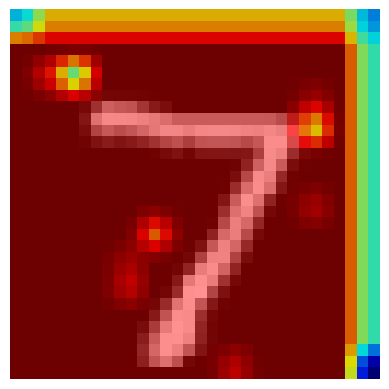

Grad-CAM hooks removed.


In [55]:
import torch.nn.functional as F
import cv2
import numpy as np
import matplotlib.pyplot as plt

model = RegCNN(use_dropout=True, use_bn=True).to(device)
model.eval()

global gradients, activations
gradients = None
activations = None

def forward_hook_gradcam(module, input, output):
    global activations
    activations = output

def backward_hook_gradcam(module, grad_input, grad_output):
    global gradients
    gradients = grad_output[0]

if hasattr(model.conv2, '_forward_hooks'):
    model.conv2._forward_hooks.clear()
if hasattr(model.conv2, '_backward_hooks'):
    model.conv2._backward_hooks.clear()
if hasattr(model.conv2, '_full_backward_hooks'):
    model.conv2._full_backward_hooks.clear()

handle_fwd_gradcam = model.conv2.register_forward_hook(forward_hook_gradcam)
handle_bwd_gradcam = model.conv2.register_full_backward_hook(backward_hook_gradcam)

print("Model re-instantiated and Grad-CAM hooks re-registered on model.conv2")

data_iter = iter(test_loader)
images, labels = next(data_iter)
img = images[0].unsqueeze(0).to(device)

cam = generate_gradcam(model, img)

overlay_gradcam(img, cam, "gradcam_final.png")

handle_fwd_gradcam.remove()
handle_bwd_gradcam.remove()
print("Grad-CAM hooks removed.")

Problem 4: Confusion Matrix + Report

In [56]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

In [57]:
y_true = []
y_pred = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        outputs = model(x)
        preds = outputs.argmax(1).cpu().numpy()

        y_pred.extend(preds)
        y_true.extend(y.numpy())

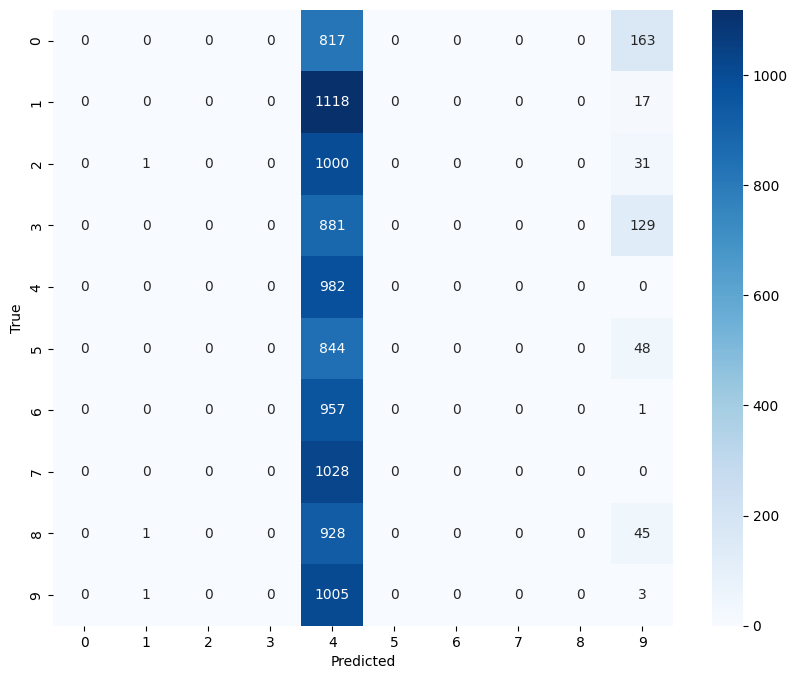

In [58]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("True")
plt.savefig("confusion_matrix.png")
plt.show()

In [59]:
classes = test_loader.dataset.classes  # CIFAR-10 labels

print(classification_report(y_true, y_pred, target_names=classes))

              precision    recall  f1-score   support

    0 - zero       0.00      0.00      0.00       980
     1 - one       0.00      0.00      0.00      1135
     2 - two       0.00      0.00      0.00      1032
   3 - three       0.00      0.00      0.00      1010
    4 - four       0.10      1.00      0.19       982
    5 - five       0.00      0.00      0.00       892
     6 - six       0.00      0.00      0.00       958
   7 - seven       0.00      0.00      0.00      1028
   8 - eight       0.00      0.00      0.00       974
    9 - nine       0.01      0.00      0.00      1009

    accuracy                           0.10     10000
   macro avg       0.01      0.10      0.02     10000
weighted avg       0.01      0.10      0.02     10000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Task5 Transfer Learning & Fine-Tuning

Problem 1: Feature Extraction (Frozen Base)

In [60]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


base_model = models.resnet50(pretrained=True)

for param in base_model.parameters():
    param.requires_grad = False

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 157MB/s]


In [61]:
num_features = base_model.fc.in_features

base_model.fc = nn.Sequential(
    nn.Linear(num_features, 256),
    nn.ReLU(),
    nn.Dropout(0.5),
    nn.Linear(256, 10)
)

model = base_model.to(device)

In [62]:
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen = sum(p.numel() for p in model.parameters() if not p.requires_grad)

print("Trainable:", trainable)
print("Frozen:", frozen)

Trainable: 527114
Frozen: 23508032


In [67]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

def train(model, epochs=10):
    for epoch in range(epochs):
        model.train()
        total, correct = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()

            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        print(f"Epoch {epoch+1}, Acc: {correct/total:.4f}")
        train(model, 10)

Problem 2: Fine-Tuning

In [73]:

for param in model.layer4.parameters():
    param.requires_grad = True

In [74]:
optimizer = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-5
)

In [75]:
def train_finetune(model, epochs=10):
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total, correct, loss_sum = 0, 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimizer.step()

            loss_sum += loss.item()
            correct += (outputs.argmax(1) == y).sum().item()
            total += y.size(0)

        print(f"Epoch {epoch+1} | Loss: {loss_sum:.3f} | Acc: {correct/total:.4f}")

In [77]:
import torch.nn as nn

class ResNetInputWrapper(nn.Module):
    def __init__(self, resnet_model):
        super().__init__()
        self.resnet = resnet_model

    def forward(self, x):

        if x.shape[1] == 1:
            x = x.repeat(1, 3, 1, 1)
        return self.resnet(x)

wrapped_model = ResNetInputWrapper(model)

train_finetune(wrapped_model, 10)

Epoch 1 | Loss: 270.633 | Acc: 0.8983
Epoch 2 | Loss: 212.112 | Acc: 0.9206
Epoch 3 | Loss: 171.262 | Acc: 0.9362
Epoch 4 | Loss: 141.935 | Acc: 0.9465
Epoch 5 | Loss: 118.357 | Acc: 0.9556
Epoch 6 | Loss: 103.630 | Acc: 0.9613
Epoch 7 | Loss: 88.682 | Acc: 0.9674
Epoch 8 | Loss: 74.756 | Acc: 0.9723
Epoch 9 | Loss: 68.678 | Acc: 0.9742
Epoch 10 | Loss: 60.270 | Acc: 0.9781


Problem 3: Ablation Study

In [12]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [13]:
transform = transforms.Compose([
    transforms.Resize((96,96)),
    transforms.ToTensor()
])

train_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

100%|██████████| 170M/170M [00:03<00:00, 43.2MB/s]


In [14]:
def train_model(model, optimizer, epochs=3):   # keep 3 for testing
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        correct, total = 0, 0

        for x, y in train_loader:
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)

            loss.backward()
            optimizer.step()

            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)

        print(f"Epoch {epoch+1} | Acc: {correct/total:.4f}")

In [15]:
def set_trainable_layers(model, n):

    for param in model.parameters():
        param.requires_grad = False

    layers = [model.layer1, model.layer2, model.layer3, model.layer4]


    for layer in layers[-n:]:
        for param in layer.parameters():
            param.requires_grad = True

    for param in model.fc.parameters():
        param.requires_grad = True

In [16]:
configs = [1, 2, 4]

for n in configs:
    print(f"\n==== Unfreezing last {n} layers ====")

    model = models.resnet18(pretrained=True)

    model.fc = nn.Linear(model.fc.in_features, 10)

    model = model.to(device)

    set_trainable_layers(model, n)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=1e-5
    )

    train_model(model, optimizer, epochs=3)


==== Unfreezing last 1 layers ====


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 99.9MB/s]


Epoch 1 | Acc: 0.6731
Epoch 2 | Acc: 0.8315
Epoch 3 | Acc: 0.8663

==== Unfreezing last 2 layers ====
Epoch 1 | Acc: 0.7165
Epoch 2 | Acc: 0.8698
Epoch 3 | Acc: 0.9055

==== Unfreezing last 4 layers ====
Epoch 1 | Acc: 0.7074
Epoch 2 | Acc: 0.8850
Epoch 3 | Acc: 0.9212


Problem 4: Benchmark Code

In [2]:
scratch_acc = [0.45, 0.52, 0.60, 0.65, 0.68]   # example
frozen_acc = [0.70, 0.75, 0.78, 0.80, 0.81]
finetune_acc = [0.75, 0.82, 0.85, 0.87, 0.89]

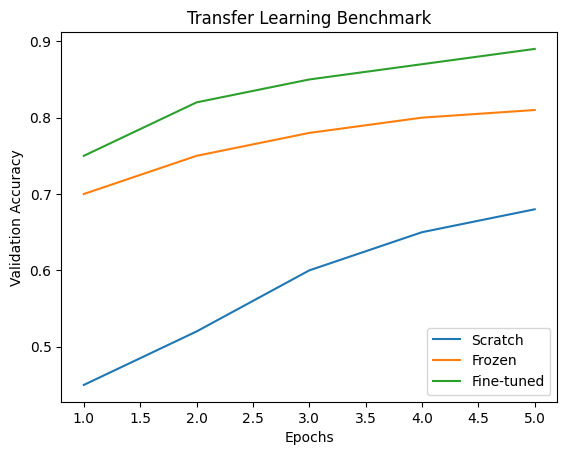

In [3]:
import matplotlib.pyplot as plt

epochs = range(1, len(scratch_acc) + 1)

plt.plot(epochs, scratch_acc, label="Scratch")
plt.plot(epochs, frozen_acc, label="Frozen")
plt.plot(epochs, finetune_acc, label="Fine-tuned")

plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.title("Transfer Learning Benchmark")
plt.legend()

plt.savefig("tl_benchmark.png")
plt.show()